# Simple Binary Classification — Morgan Fingerprints as Direct Features

Instead of collapsing each drug pair down to a single Tanimoto similarity scalar (as in `structural_sim_notebook.ipynb`), this notebook feeds the **raw Morgan bit-vector fingerprints** of both drugs directly into a classifier as input features.

**Task:** predict whether a drug pair is an *adverse* interaction (label = 1) or a *non-interacting* pair (label = 0), using only chemical structure (SMILES → Morgan fingerprint), with no biological/target features.

**Pipeline**
1. Load labeled pair data (adverse vs. non-interacting) with SMILES for both drugs.
2. Generate Morgan fingerprints (`radius=2`, `nBits=2048` by default) for each drug in each pair.
3. Combine the two per-drug fingerprints into one feature vector per pair (several combination strategies supported).
4. Train/test split (stratified).
5. Train baseline models: Logistic Regression + Random Forest.
6. Evaluate with accuracy, precision/recall/F1, ROC-AUC, PR-AUC, confusion matrices, ROC/PR curves.
7. Inspect which fingerprint bits are most informative.
8. Persist the trained model + config to disk.


In [1]:
# Imports
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Configuration

All tunable knobs live here. `MAX_PAIRS_PER_CLASS` caps how many rows are drawn from each class before fingerprinting - the full adverse set (~478k pairs) and non-interacting set (~163k pairs) fingerprint fine, but training a Random Forest on the full concatenated 4096-bit feature matrix is slow, so we subsample by default. Set it to `None` to use every available row.


In [2]:
# --- Data sources (same parquet files used in structural_sim_notebook.ipynb) ---
ADVERSE_PAIRS_PATH = (
    r"C:\Users\ashto\OneDrive - Eastern Connecticut State University\Project 5. Data"
    r"\processed\a_potential_final_df\adverse_final_df.parquet"
)
NON_INTERACTING_PAIRS_PATH = (
    r"C:\Users\ashto\OneDrive - Eastern Connecticut State University\Project 5. Data"
    r"\processed\a_potential_final_df\non_interacting_pairs_final.parquet"
)
DRUG_A_COL = "smiles_1"
DRUG_B_COL = "smiles_2"

# --- Morgan fingerprint settings ---
FP_RADIUS = 2
FP_N_BITS = 2048

# --- Feature combination strategy for turning two per-drug fingerprints into one pair vector ---
# "concat"  -> [fp_a | fp_b]                              (2 * FP_N_BITS features, order-sensitive)
# "sum"     -> fp_a + fp_b                                (FP_N_BITS features, order-invariant, values in {0,1,2})
# "maxmin"  -> [elementwise max(fp_a, fp_b) | min(fp_a, fp_b)]  (2 * FP_N_BITS features, order-invariant)
FEATURE_MODE = "maxmin"

# --- Sampling / split ---
MAX_PAIRS_PER_CLASS = 25_000  # set to None to use all available pairs
TEST_SIZE = 0.2 # proportion of the dataset to include in the test split
RANDOM_STATE = 42 # random seed for reproducibility

# --- Output ---
MODEL_OUTPUT_DIR = Path("models") / "morgan_fp_binary_classifier"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # create the output directory if it doesn't exist


## 1. Load & Label Data

Load the adverse and non-interacting pair tables, tag each with a binary label, optionally subsample for speed, and concatenate into one working dataframe.


In [3]:
def load_labeled_pairs(path, label, drug_a_col, drug_b_col, max_rows=None, random_state=RANDOM_STATE):
    """Load a pair table, keep only the columns we need, and attach a binary label."""
    columns_needed = ["drug1_id", "drug2_id", "drug1_name", "drug2_name", drug_a_col, drug_b_col] # columns to keep from the parquet file
    df = pd.read_parquet(path, columns=columns_needed, engine="pyarrow") # read the parquet file with only the needed columns

    if max_rows is not None and len(df) > max_rows:  # if the dataframe has more rows than the maximum allowed
        df = df.sample(n=max_rows, random_state=random_state)  # randomly sample the maximum allowed rows

    df = df.rename(columns={drug_a_col: "smiles_1", drug_b_col: "smiles_2"}) # rename the drug columns to a standard format
    df["label"] = label # attach the binary label to the dataframe
    return df.reset_index(drop=True) # reset the index after any sampling and return the dataframe

# Here we set the binary label to each of the datasets
adverse_df = load_labeled_pairs( # load the adverse pairs with a label of 1
    ADVERSE_PAIRS_PATH, label=1, drug_a_col=DRUG_A_COL, drug_b_col=DRUG_B_COL, max_rows=MAX_PAIRS_PER_CLASS # maximum number of adverse pairs to load
)
non_interacting_df = load_labeled_pairs( # load the non-interacting pairs with a label of 0
    NON_INTERACTING_PAIRS_PATH, label=0, drug_a_col=DRUG_A_COL, drug_b_col=DRUG_B_COL, max_rows=MAX_PAIRS_PER_CLASS # maximum number of non-interacting pairs to load
)

pairs_df = pd.concat([adverse_df, non_interacting_df], ignore_index=True) # combine the adverse and non-interacting pairs into a single dataframe

print(f"Adverse pairs loaded:         {len(adverse_df):,}")
print(f"Non-interacting pairs loaded: {len(non_interacting_df):,}")
print(f"Total pairs:                  {len(pairs_df):,}")
pairs_df["label"].value_counts().rename({1: "adverse", 0: "non_interacting"})


Adverse pairs loaded:         25,000
Non-interacting pairs loaded: 25,000
Total pairs:                  50,000


label
adverse            25000
non_interacting    25000
Name: count, dtype: int64

## 2. SMILES → Morgan Bit-Vector Fingerprints

Same fingerprint generator as `structural_sim_notebook.ipynb` (`AllChem.GetMorganFingerprintAsBitVect`), but here each fingerprint is converted straight to a NumPy `uint8` array so it can be used as raw model input instead of being reduced to a single similarity score.


In [4]:
def smiles_to_morgan_array(smiles, radius=FP_RADIUS, n_bits=FP_N_BITS):
    """Convert a single SMILES string to a Morgan fingerprint as a uint8 NumPy array, or None if invalid."""
    if pd.isna(smiles) or not isinstance(smiles, str): # check if the SMILES is missing or not a string
        return None

    smiles = smiles.strip() # remove leading and trailing whitespace
    if not smiles: # check if the SMILES is empty after stripping
        return None

    mol = Chem.MolFromSmiles(smiles) # convert the SMILES string to an RDKit molecule object
    if mol is None: # check if the conversion failed
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits) # generate the Morgan fingerprint as a bit vector
    arr = np.zeros((n_bits,), dtype=np.uint8) # create an empty array to hold the fingerprint bits
    DataStructs.ConvertToNumpyArray(fp, arr) # convert the bit vector to a NumPy array
    return arr


def batch_smiles_to_arrays(smiles_series, radius=FP_RADIUS, n_bits=FP_N_BITS):
    """Convert a Series of SMILES to a (n_rows, n_bits) uint8 array plus a boolean validity mask."""
    n = len(smiles_series) # number of SMILES strings in the input series
    fp_matrix = np.zeros((n, n_bits), dtype=np.uint8) # initialize the fingerprint matrix with zeros
    valid_mask = np.zeros((n,), dtype=bool) # initialize the validity mask with False values

    for i, smiles in enumerate(smiles_series): # iterate over each SMILES string and its index
        arr = smiles_to_morgan_array(smiles, radius=radius, n_bits=n_bits) # convert the SMILES string to a Morgan fingerprint array
        if arr is not None: # only update the fingerprint matrix and validity mask if the conversion was successful
            fp_matrix[i] = arr # update the fingerprint matrix with the valid fingerprint array
            valid_mask[i] = True # mark the fingerprint as valid

    return fp_matrix, valid_mask # return the fingerprint matrix and the validity mask


t0 = time.time() # start the timer for fingerprinting the SMILES pairs
fp_drug1, valid_1 = batch_smiles_to_arrays(pairs_df["smiles_1"]) # convert the first set of SMILES strings to Morgan fingerprint arrays
fp_drug2, valid_2 = batch_smiles_to_arrays(pairs_df["smiles_2"]) # convert the second set of SMILES strings to Morgan fingerprint arrays
print(f"Fingerprinted {len(pairs_df):,} pairs in {time.time() - t0:.1f}s") # print the number of successfully fingerprinted pairs and the time taken

valid_pair_mask = valid_1 & valid_2 # create a mask indicating which pairs have valid fingerprints for both drugs
n_dropped = (~valid_pair_mask).sum() # count the number of pairs with invalid fingerprints
print(f"Dropped {n_dropped:,} pairs with an invalid/unparseable SMILES ({n_dropped / len(pairs_df):.2%})") # print the number and percentage of dropped pairs

pairs_df = pairs_df.loc[valid_pair_mask].reset_index(drop=True) # keep only the valid pairs in the DataFrame
fp_drug1 = fp_drug1[valid_pair_mask] # keep only the valid fingerprints for the first drug
fp_drug2 = fp_drug2[valid_pair_mask] # keep only the valid fingerprints for the second drug

print(f"Remaining pairs: {len(pairs_df):,}") # print the number of remaining valid pairs (Should never drop any since the final dataset should only have valid SMILES pairs)


Fingerprinted 50,000 pairs in 37.6s
Dropped 0 pairs with an invalid/unparseable SMILES (0.00%)
Remaining pairs: 50,000


## 3. Combine Per-Drug Fingerprints into Pair Features

A DDI pair has no inherent "drug 1 / drug 2" ordering, so naively concatenating `[fp_a | fp_b]` lets the model implicitly memorize column-position → drug-identity patterns rather than learning structure-driven interaction signal. `"maxmin"` (elementwise max and min across the two fingerprints) is order-invariant and is the recommended default; `"concat"` and `"sum"` are provided for comparison.


In [5]:
def build_pair_features(fp_a, fp_b, mode=FEATURE_MODE): # Combine two fingerprint matrices into pair-level features based on the specified mode.
    """Combine two (n_rows, n_bits) fingerprint matrices into one pair-level feature matrix."""
    if mode == "concat": # Concatenate the two fingerprint matrices horizontally.
        return np.hstack([fp_a, fp_b]) # Concatenated feature matrix of shape (n_rows, 2 * n_bits)
    if mode == "sum":
        return (fp_a.astype(np.uint8) + fp_b.astype(np.uint8)) # Element-wise sum of the two fingerprint matrices.
    if mode == "maxmin": # Create pair-level features by taking element-wise maximum and minimum, then concatenating.
        return np.hstack([np.maximum(fp_a, fp_b), np.minimum(fp_a, fp_b)]) # Feature matrix of shape (n_rows, 2 * n_bits)
    raise ValueError(f"Unknown FEATURE_MODE: {mode!r}") # Raise an error if the specified feature mode is not recognized.


X = build_pair_features(fp_drug1, fp_drug2, mode=FEATURE_MODE) # Build the pair-level feature matrix based on the specified feature mode.
y = pairs_df["label"].to_numpy() # Convert the label column to a NumPy array for model training.

print(f"Feature matrix shape: {X.shape} (mode={FEATURE_MODE!r})") # Print the shape of the feature matrix and the feature mode.
print(f"Label distribution: {np.bincount(y)} (index 0 = non_interacting, 1 = adverse)") # Print the distribution of labels in the dataset.


Feature matrix shape: (50000, 4096) (mode='maxmin')
Label distribution: [25000 25000] (index 0 = non_interacting, 1 = adverse)


## 4. Train / Test Split


In [6]:
X_train, X_test, y_train, y_test = train_test_split( # Split the dataset into training and testing sets
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE # Ensure reproducibility and maintain class distribution
)

print(f"Train: {X_train.shape}, positive rate = {y_train.mean():.3f}") # Print training set size and positive class rate
print(f"Test:  {X_test.shape}, positive rate = {y_test.mean():.3f}")


Train: (40000, 4096), positive rate = 0.500
Test:  (10000, 4096), positive rate = 0.500


## 5. Train Baseline Models

Two simple, complementary baselines:
- **Logistic Regression** — fast, interpretable, linear decision boundary directly over fingerprint bits.
- **Random Forest** — captures non-linear bit interactions, gives feature importances for free.

Both use `class_weight="balanced"` to account for the class imbalance between adverse and non-interacting pairs.


In [7]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

fitted_models = {}
for name, model in models.items(): # Iterate over each model and fit it to the training data
    t0 = time.time() # Record the start time for fitting the model
    model.fit(X_train, y_train) # Fit the model to the training data
    fitted_models[name] = model # Store the fitted model in the dictionary for later use
    print(f"Fit {name} in {time.time() - t0:.1f}s") # Print the time taken to fit each model


c:\Users\ashto\anaconda3\envs\ddi_stable\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Fit logistic_regression in 33.9s
Fit random_forest in 51.0s


## 6. Evaluation

Compute standard classification metrics on the held-out test set for both models, including PR-AUC (informative given the class imbalance) alongside ROC-AUC.


In [8]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba


results = []
predictions = {} # Dictionary to store predictions and probabilities for each model
for name, model in fitted_models.items(): # Iterate over each fitted model and evaluate it on the test set
    metrics, y_pred, y_proba = evaluate_model(model, X_test, y_test, name) # Evaluate the model on the test set
    results.append(metrics) # Append the evaluation metrics to the results list
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba} # Store the predictions and probabilities for the model

results_df = pd.DataFrame(results).set_index("model").round(4) # Convert the results list to a DataFrame for easy viewing
display(results_df) # Display the evaluation results for all models


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
logistic_regression,0.7561,0.7415,0.7864,0.7633,0.8363,0.8210
random_forest,0.7571,0.7421,0.7880,0.7644,0.8377,0.8282


=== logistic_regression ===
                 precision    recall  f1-score   support

non_interacting       0.77      0.73      0.75      5000
        adverse       0.74      0.79      0.76      5000

       accuracy                           0.76     10000
      macro avg       0.76      0.76      0.76     10000
   weighted avg       0.76      0.76      0.76     10000

=== random_forest ===
                 precision    recall  f1-score   support

non_interacting       0.77      0.73      0.75      5000
        adverse       0.74      0.79      0.76      5000

       accuracy                           0.76     10000
      macro avg       0.76      0.76      0.76     10000
   weighted avg       0.76      0.76      0.76     10000



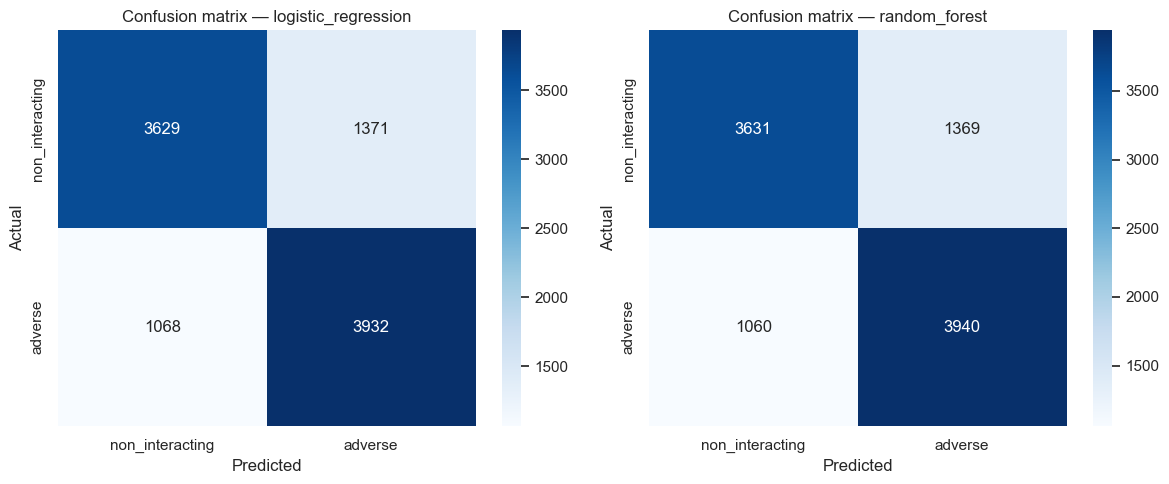

In [9]:
for name in fitted_models: # Iterate over each fitted model and print its classification report
    print(f"=== {name} ===")
    print(classification_report(y_test, predictions[name]["y_pred"], target_names=["non_interacting", "adverse"]))

fig, axes = plt.subplots(1, len(fitted_models), figsize=(6 * len(fitted_models), 5)) # Create subplots for confusion matrices of each model
if len(fitted_models) == 1: # Ensure axes is always a list, even if there's only one subplot
    axes = [axes]

for ax, name in zip(axes, fitted_models):
    cm = confusion_matrix(y_test, predictions[name]["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["non_interacting", "adverse"],
        yticklabels=["non_interacting", "adverse"],
        ax=ax,
    )
    ax.set_title(f"Confusion matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


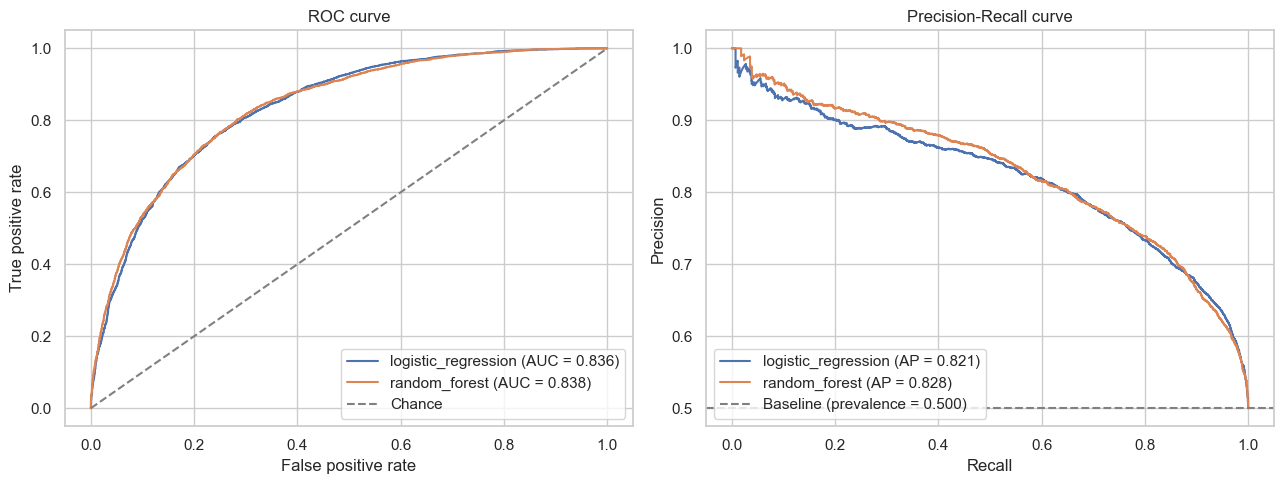

In [10]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

for name in fitted_models:
    y_proba = predictions[name]["y_proba"]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax_pr.plot(recall, precision, label=f"{name} (AP = {average_precision_score(y_test, y_proba):.3f})")

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curve")
ax_roc.legend(loc="lower right")

baseline_precision = y_test.mean()
ax_pr.axhline(baseline_precision, linestyle="--", color="grey", label=f"Baseline (prevalence = {baseline_precision:.3f})")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall curve")
ax_pr.legend(loc="lower left")

plt.tight_layout()
plt.show()


## 7. Which Fingerprint Bits Matter Most?

Under `FEATURE_MODE = "maxmin"`, feature indices `[0, FP_N_BITS)` are the elementwise-**max** bits (bit set if either drug has it) and `[FP_N_BITS, 2*FP_N_BITS)` are the elementwise-**min** bits (bit set only if both drugs share it). This lets us see whether "shared substructure" or "either-drug substructure" bits drive predictions.

The "Max" Half (idx < n_bits): Acts as a logical OR. The bit is activated (set to 1) if either molecule in the pair contains the specific chemical substructure. It captures the total structural space of the pair.

The "Min" Half (idx >= n_bits): Acts as a logical AND. The bit is activated only if both molecules share that exact substructure. It identifies structural commonalities.

The describe_bit_index function acts as a translator. It takes a flattened machine learning feature index (e.g., feature 1530) and maps it back to its chemical context: "This is fingerprint bit 506, and it represents a shared ('min') substructure."

##

If you simply concatenate fingerprints ([Drug A, Drug B]), the model treats A+B differently than B+A. The maxmin approach solves this by synthesizing a new feature array that is twice the length of a single fingerprint:

Top logistic regression coefficients (by absolute value):


,fp_bit,half,coefficient
1159,1159,max,-3.117041
1505,1505,max,-3.029509
1132,1132,max,2.976231
78,78,max,-2.774695
1899,1899,max,2.769373
1247,1247,max,2.647224
1883,1883,max,-2.594021
365,365,max,-2.565987
413,413,max,2.358441
1062,1062,max,-2.329553



Top random forest feature importances:


,fp_bit,half,importance
3798,1750,min,0.007352
3428,1380,min,0.007041
3921,1873,min,0.006789
3136,1088,min,0.003329
3105,1057,min,0.003019
1199,1199,max,0.002998
561,561,max,0.002756
2698,650,min,0.002751
1088,1088,max,0.002750
3247,1199,min,0.002686


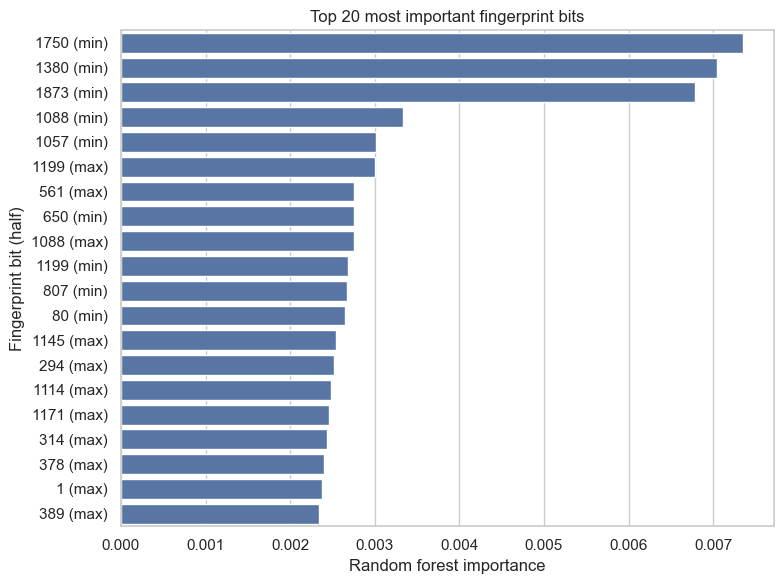

In [11]:
def describe_bit_index(idx, mode=FEATURE_MODE, n_bits=FP_N_BITS):
    """Map a flattened feature index back to (fingerprint_bit, half_label) for interpretability."""
    if mode == "sum":
        return idx, "sum"
    half = "max" if idx < n_bits else "min"
    bit = idx if idx < n_bits else idx - n_bits
    return bit, half


TOP_N = 20

logreg = fitted_models["logistic_regression"]
coef_importance = pd.DataFrame(
    {
        "feature_index": np.arange(X_train.shape[1]),
        "coefficient": logreg.coef_[0],
    }
)
coef_importance[["fp_bit", "half"]] = coef_importance["feature_index"].apply(
    lambda i: pd.Series(describe_bit_index(i))
)
top_logreg = coef_importance.reindex(
    coef_importance["coefficient"].abs().sort_values(ascending=False).index
).head(TOP_N)

print("Top logistic regression coefficients (by absolute value):")
display(top_logreg[["fp_bit", "half", "coefficient"]])

rf = fitted_models["random_forest"]
rf_importance = pd.DataFrame(
    {
        "feature_index": np.arange(X_train.shape[1]),
        "importance": rf.feature_importances_,
    }
).sort_values("importance", ascending=False).head(TOP_N)
rf_importance[["fp_bit", "half"]] = rf_importance["feature_index"].apply(
    lambda i: pd.Series(describe_bit_index(i))
)

print("\nTop random forest feature importances:")
display(rf_importance[["fp_bit", "half", "importance"]])

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=rf_importance, x="importance", y=rf_importance["fp_bit"].astype(str) + " (" + rf_importance["half"] + ")", ax=ax)
ax.set_ylabel("Fingerprint bit (half)")
ax.set_xlabel("Random forest importance")
ax.set_title(f"Top {TOP_N} most important fingerprint bits")
plt.tight_layout()
plt.show()


## 8. Persist the Best Model

Pick the model with the highest ROC-AUC and save it alongside the run configuration so it can be reloaded for inference without re-running this notebook.


In [12]:
best_model_name = results_df["roc_auc"].idxmax()
best_model = fitted_models[best_model_name]
print(f"Best model by ROC-AUC: {best_model_name} ({results_df.loc[best_model_name, 'roc_auc']:.4f})")

model_path = MODEL_OUTPUT_DIR / f"{best_model_name}.joblib"
config_path = MODEL_OUTPUT_DIR / "run_config.json"

joblib.dump(best_model, model_path)

run_config = {
    "best_model": best_model_name,
    "feature_mode": FEATURE_MODE,
    "fp_radius": FP_RADIUS,
    "fp_n_bits": FP_N_BITS,
    "max_pairs_per_class": MAX_PAIRS_PER_CLASS,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "metrics": results_df.to_dict(orient="index"),
}
with open(config_path, "w") as f:
    json.dump(run_config, f, indent=2)

print(f"Saved model to:  {model_path}")
print(f"Saved config to: {config_path}")


Best model by ROC-AUC: random_forest (0.8377)
Saved model to:  models\morgan_fp_binary_classifier\random_forest.joblib
Saved config to: models\morgan_fp_binary_classifier\run_config.json


## 9. Baseline Classifier — Similarity Score as Sole Feature

For comparison against the raw-fingerprint models above, train a simple logistic regression using **only** the scalar Tanimoto `similarity_score` (produced by `structural_sim_notebook.ipynb` and persisted to `adverse_structural_sim.parquet` / `non_interacting_structural_sim.parquet`) as a single feature. This quantifies how much predictive signal is captured by structural similarity alone.

In [13]:
SIM_RANDOM_STATE = 42
SIM_TEST_SIZE = 0.2

adverse_sim_df = pd.read_parquet("adverse_structural_sim.parquet").assign(label=1)
non_interacting_sim_df = pd.read_parquet("non_interacting_structural_sim.parquet").assign(label=0)

sim_pairs_df = pd.concat([adverse_sim_df, non_interacting_sim_df], ignore_index=True)
print(f"Adverse pairs:         {len(adverse_sim_df):,}")
print(f"Non-interacting pairs: {len(non_interacting_sim_df):,}")
print(f"Total pairs:           {len(sim_pairs_df):,}")
sim_pairs_df["label"].value_counts().rename({1: "adverse", 0: "non_interacting"})

Adverse pairs:         478,324
Non-interacting pairs: 162,893
Total pairs:           641,217


label
adverse            478324
non_interacting    162893
Name: count, dtype: int64

In [14]:
X_sim = sim_pairs_df[["similarity_score"]].to_numpy()
y_sim = sim_pairs_df["label"].to_numpy()

X_sim_train, X_sim_test, y_sim_train, y_sim_test = train_test_split(
    X_sim, y_sim, test_size=SIM_TEST_SIZE, stratify=y_sim, random_state=SIM_RANDOM_STATE
)

sim_logreg = LogisticRegression(class_weight="balanced", random_state=SIM_RANDOM_STATE)
sim_logreg.fit(X_sim_train, y_sim_train)

print(f"Train: {X_sim_train.shape}, positive rate = {y_sim_train.mean():.3f}")
print(f"Test:  {X_sim_test.shape}, positive rate = {y_sim_test.mean():.3f}")
print(f"Coefficient (similarity_score): {sim_logreg.coef_[0][0]:.4f}, intercept: {sim_logreg.intercept_[0]:.4f}")

Train: (512973, 1), positive rate = 0.746
Test:  (128244, 1), positive rate = 0.746
Coefficient (similarity_score): 5.6079, intercept: -0.5365


In [15]:
y_sim_pred = sim_logreg.predict(X_sim_test)
y_sim_proba = sim_logreg.predict_proba(X_sim_test)[:, 1]

sim_metrics = {
    "accuracy": accuracy_score(y_sim_test, y_sim_pred),
    "precision": precision_score(y_sim_test, y_sim_pred),
    "recall": recall_score(y_sim_test, y_sim_pred),
    "f1": f1_score(y_sim_test, y_sim_pred),
    "roc_auc": roc_auc_score(y_sim_test, y_sim_proba),
    "pr_auc": average_precision_score(y_sim_test, y_sim_proba),
}
display(pd.Series(sim_metrics).round(4).to_frame("similarity_score_only"))

print(classification_report(y_sim_test, y_sim_pred, target_names=["non_interacting", "adverse"]))

,similarity_score_only
accuracy,0.5368
precision,0.7852
recall,0.5217
f1,0.6269
roc_auc,0.5760
pr_auc,0.7949


                 precision    recall  f1-score   support

non_interacting       0.29      0.58      0.39     32579
        adverse       0.79      0.52      0.63     95665

       accuracy                           0.54    128244
      macro avg       0.54      0.55      0.51    128244
   weighted avg       0.66      0.54      0.57    128244



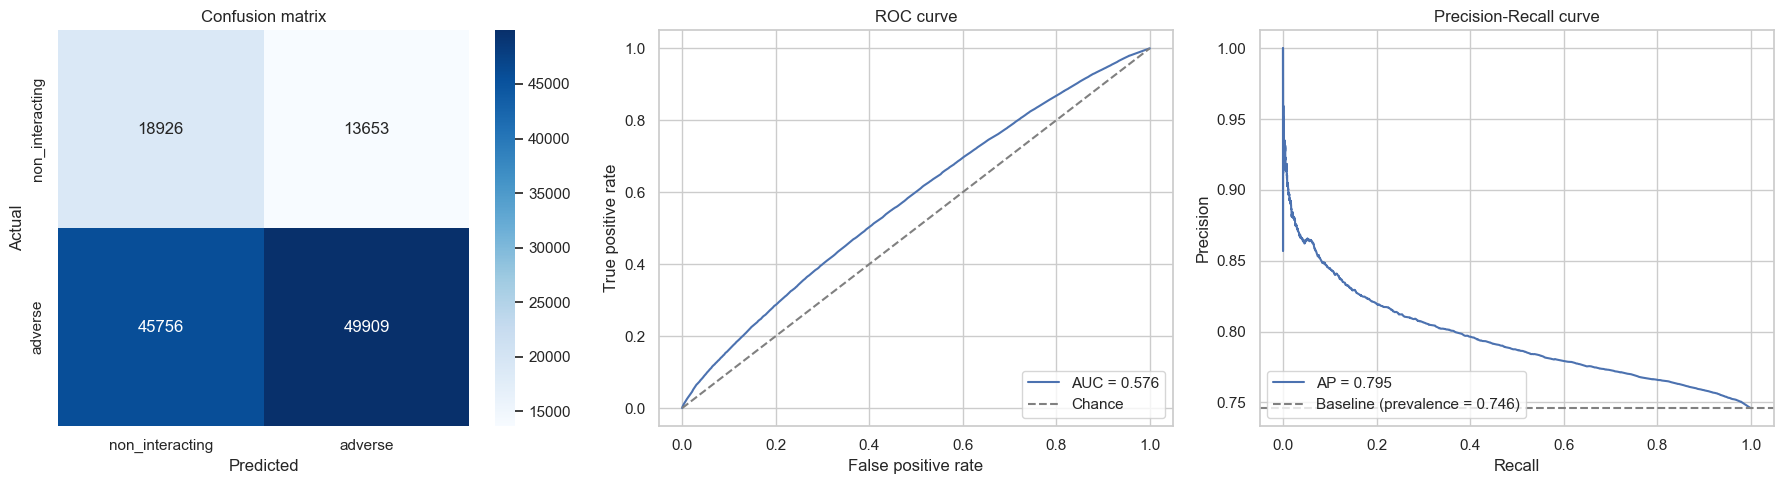

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_sim_test, y_sim_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["non_interacting", "adverse"],
    yticklabels=["non_interacting", "adverse"],
    ax=axes[0],
)
axes[0].set_title("Confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_sim_test, y_sim_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {sim_metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[1].set_title("ROC curve")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend(loc="lower right")

precision, recall, _ = precision_recall_curve(y_sim_test, y_sim_proba)
axes[2].plot(recall, precision, label=f"AP = {sim_metrics['pr_auc']:.3f}")
axes[2].axhline(y_sim_test.mean(), linestyle="--", color="grey", label=f"Baseline (prevalence = {y_sim_test.mean():.3f})")
axes[2].set_title("Precision-Recall curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()